# 03 — Anomaly Detection

Detect and classify anomalous behavior across 180 Bitcoin miners over 14 days of 5-minute telemetry.

**Approach:**
1. Statistical (z-score, IQR) per-miner anomaly detection
2. Contextual anomalies — deviation from fleet at each timestamp
3. Isolation Forest — multivariate unsupervised detection
4. Downtime & outage analysis
5. Container-level correlated failures
6. Correlation with operating conditions
7. Anomaly summary & operational recommendations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

## 1. Load & Prep

In [2]:
tel = pd.read_csv('site_telemetry.csv', na_values=[''], parse_dates=['timestamp'])
reg = pd.read_csv('miner_registry.csv')

# Merge nominal specs onto telemetry
tel = tel.merge(reg[['miner_id', 'nominal_hashrate_th', 'nominal_power_w', 'nominal_efficiency_wth']],
                on='miner_id', how='left')

# Derived columns
tel['hashrate_pct'] = tel['hashrate_th_5m'] / tel['nominal_hashrate_th'] * 100
total_shares = tel['accepted_shares'] + tel['rejected_shares'] + tel['stale_shares']
tel['reject_rate'] = tel['rejected_shares'] / total_shares.replace(0, np.nan)
tel['hour'] = tel['timestamp'].dt.hour

# Mining-only subset for most analyses
mining = tel[tel['status'] == 'mining'].copy()

print(f'Total rows: {len(tel):,}  |  Mining rows: {len(mining):,}')
print(f'Date range: {tel.timestamp.min()} to {tel.timestamp.max()}')
print(f'Miners: {tel.miner_id.nunique()}  |  Containers: {tel.container.nunique()}')
print(f'Models: {reg.model.value_counts().to_dict()}')
tel.head(3)

Total rows: 725,760  |  Mining rows: 723,533
Date range: 2026-04-09 00:00:00 to 2026-04-22 23:55:00
Miners: 180  |  Containers: 3
Models: {'S21': 75, 'S19XP': 65, 'M63': 30, 'M56S': 10}


,timestamp,miner_id,container,position,model,status,power_mode,hashrate_th_5m,hashrate_th_avg,power_w,...,stale_shares,frequency_mhz,uptime_hours,electricity_rate_usd_kwh,nominal_hashrate_th,nominal_power_w,nominal_efficiency_wth,hashrate_pct,reject_rate,hour
0,2026-04-09,MNR-0001,A,R1_01,S21,mining,normal,197.00,198.69,3504.2,...,0.0,493.6,1.8,0.0276,200,3500,17.5,98.500,0.0,0
1,2026-04-09,MNR-0002,A,R1_02,S21,mining,normal,204.37,200.08,3516.7,...,0.0,498.8,0.0,0.0276,200,3500,17.5,102.185,0.0,0
2,2026-04-09,MNR-0003,A,R1_03,S21,mining,normal,199.78,198.78,3478.5,...,0.0,514.3,0.0,0.0276,200,3500,17.5,99.890,0.0,0


---
## 2. Statistical Anomaly Detection

For each miner, compute z-scores on key metrics and flag readings with |z| > 3.  
Cross-check with IQR method (outside Q1 - 1.5*IQR, Q3 + 1.5*IQR).

In [3]:
METRICS = ['chip_temp_c', 'efficiency_wth', 'hashrate_th_5m', 'reject_rate']
METRIC_LABELS = {'chip_temp_c': 'Chip Temp', 'efficiency_wth': 'Efficiency',
                 'hashrate_th_5m': 'Hashrate', 'reject_rate': 'Reject Rate'}

# --- Z-score per miner ---
grouped = mining.groupby('miner_id')[METRICS]
means = grouped.transform('mean')
stds = grouped.transform('std')

for m in METRICS:
    mining[f'z_{m}'] = (mining[m] - means[m]) / stds[m].replace(0, np.nan)

# Flag z-score anomalies
z_cols = [f'z_{m}' for m in METRICS]
for m in METRICS:
    mining[f'anom_z_{m}'] = mining[f'z_{m}'].abs() > 3

mining['any_z_anom'] = mining[[f'anom_z_{m}' for m in METRICS]].any(axis=1)

# --- IQR per miner ---
q1 = grouped.transform(lambda x: x.quantile(0.25))
q3 = grouped.transform(lambda x: x.quantile(0.75))
iqr = q3 - q1

for m in METRICS:
    lo = q1[m] - 1.5 * iqr[m]
    hi = q3[m] + 1.5 * iqr[m]
    mining[f'anom_iqr_{m}'] = (mining[m] < lo) | (mining[m] > hi)

mining['any_iqr_anom'] = mining[[f'anom_iqr_{m}' for m in METRICS]].any(axis=1)

# Summary
print('=== Z-score anomalies (|z|>3) ===')
for m in METRICS:
    n = mining[f'anom_z_{m}'].sum()
    print(f'  {METRIC_LABELS[m]:15s}: {n:6,} readings ({n/len(mining)*100:.2f}%)')
print(f'  {"Any metric":15s}: {mining.any_z_anom.sum():6,}')

print('\n=== IQR anomalies ===')
for m in METRICS:
    n = mining[f'anom_iqr_{m}'].sum()
    print(f'  {METRIC_LABELS[m]:15s}: {n:6,} readings ({n/len(mining)*100:.2f}%)')
print(f'  {"Any metric":15s}: {mining.any_iqr_anom.sum():6,}')

=== Z-score anomalies (|z|>3) ===
  Chip Temp      :    682 readings (0.09%)
  Efficiency     : 11,994 readings (1.66%)
  Hashrate       : 12,853 readings (1.78%)
  Reject Rate    :     18 readings (0.00%)
  Any metric     : 15,182

=== IQR anomalies ===
  Chip Temp      :    110 readings (0.02%)
  Efficiency     : 35,158 readings (4.86%)
  Hashrate       : 40,510 readings (5.60%)
  Reject Rate    :     18 readings (0.00%)
  Any metric     : 43,183


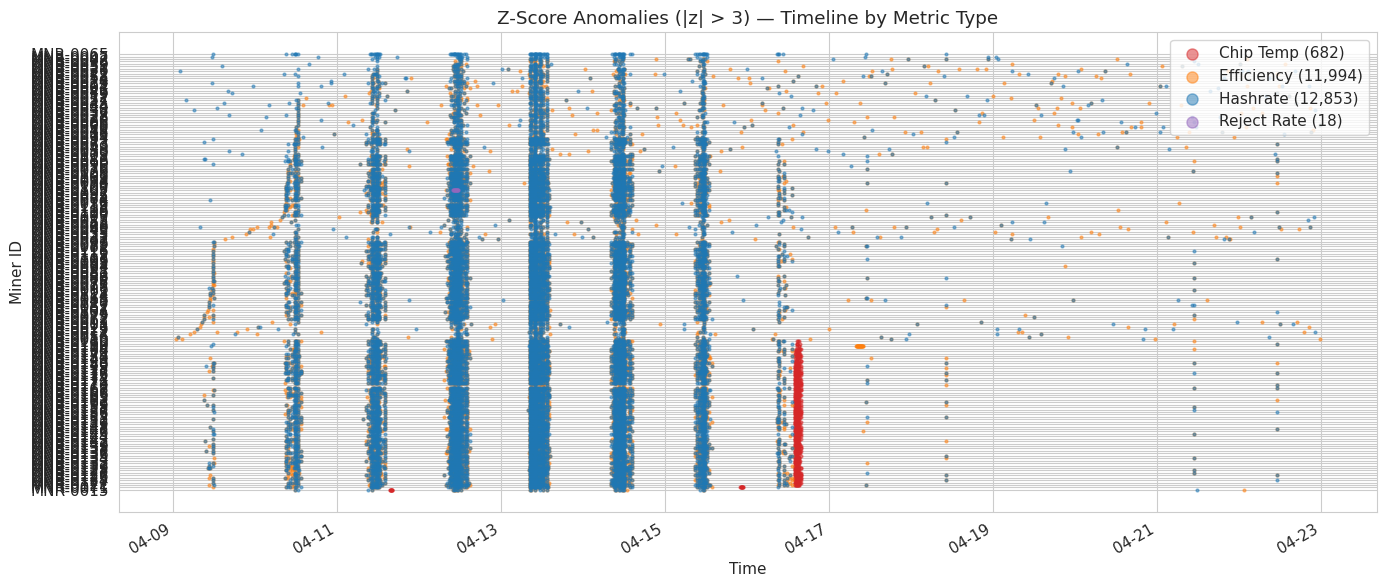

In [4]:
# Timeline of anomalous readings color-coded by metric type
fig, ax = plt.subplots(figsize=(14, 6))

colors = {'chip_temp_c': '#d62728', 'efficiency_wth': '#ff7f0e',
           'hashrate_th_5m': '#1f77b4', 'reject_rate': '#9467bd'}

for m in METRICS:
    mask = mining[f'anom_z_{m}']
    sub = mining.loc[mask]
    if len(sub) == 0:
        continue
    ax.scatter(sub['timestamp'], sub['miner_id'], s=4, alpha=0.5,
               color=colors[m], label=f'{METRIC_LABELS[m]} ({len(sub):,})')

ax.set_xlabel('Time')
ax.set_ylabel('Miner ID')
ax.set_title('Z-Score Anomalies (|z| > 3) — Timeline by Metric Type')
ax.legend(markerscale=4, loc='upper right')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

---
## 3. Contextual Anomaly Detection

Compare each miner to the fleet median at the same timestamp.  
A miner running 15 degC hotter than peers *right now* is a contextual anomaly,
even if its absolute temperature is within its own historical range.

In [5]:
# Fleet median per timestamp (computed per model to be fair)
fleet_med = mining.groupby(['timestamp', 'model'])[['chip_temp_c', 'efficiency_wth']].transform('median')

mining['dev_chip_temp'] = mining['chip_temp_c'] - fleet_med['chip_temp_c']
mining['dev_efficiency'] = mining['efficiency_wth'] - fleet_med['efficiency_wth']

# Flag contextual anomalies: chip_temp > 10C above fleet, efficiency > 3 W/TH above fleet
mining['ctx_anom_temp'] = mining['dev_chip_temp'] > 10
mining['ctx_anom_eff'] = mining['dev_efficiency'] > 3

print(f'Contextual temp anomalies (>10C above model fleet): {mining.ctx_anom_temp.sum():,}')
print(f'Contextual efficiency anomalies (>3 W/TH above model fleet): {mining.ctx_anom_eff.sum():,}')

# Top offenders
ctx_temp_miners = mining[mining.ctx_anom_temp].groupby('miner_id').size().sort_values(ascending=False)
print(f'\nTop 10 miners by contextual temp anomaly count:')
print(ctx_temp_miners.head(10).to_string())

Contextual temp anomalies (>10C above model fleet): 619
Contextual efficiency anomalies (>3 W/TH above model fleet): 3,525

Top 10 miners by contextual temp anomaly count:
miner_id
MNR-0160    29
MNR-0175    24
MNR-0171    24
MNR-0161    24
MNR-0157    24
MNR-0158    24
MNR-0159    24
MNR-0163    24
MNR-0162    24
MNR-0156    24


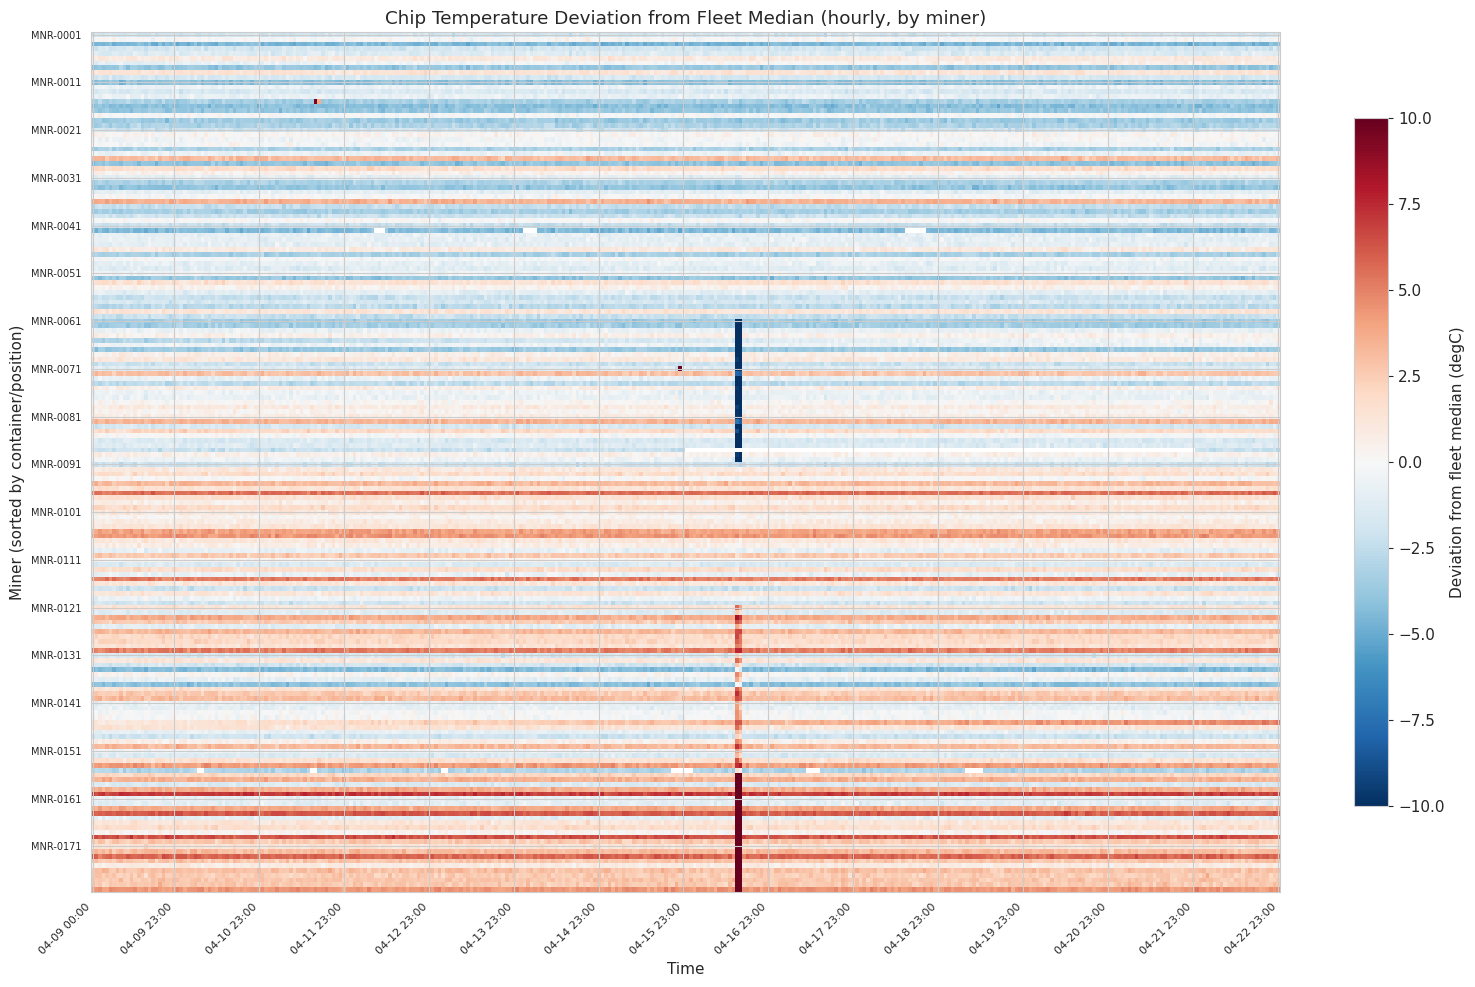

In [6]:
# Heatmap: miner x time, color = deviation from fleet median (chip_temp)
# Downsample to hourly for readability
mining_hourly = mining.set_index('timestamp').groupby('miner_id').resample('1h').agg(
    dev_chip_temp=('dev_chip_temp', 'mean')
).reset_index()

pivot = mining_hourly.pivot(index='miner_id', columns='timestamp', values='dev_chip_temp')

# Sort miners by container for spatial grouping
miner_order = reg.sort_values(['container', 'position'])['miner_id'].tolist()
pivot = pivot.reindex([m for m in miner_order if m in pivot.index])

fig, ax = plt.subplots(figsize=(16, 10))
im = ax.imshow(pivot.values, aspect='auto', cmap='RdBu_r', vmin=-10, vmax=10,
               interpolation='nearest')
cbar = fig.colorbar(im, ax=ax, label='Deviation from fleet median (degC)', shrink=0.8)

# Y-axis: show every 10th miner
ytick_idx = np.arange(0, len(pivot), 10)
ax.set_yticks(ytick_idx)
ax.set_yticklabels(pivot.index[ytick_idx], fontsize=7)

# X-axis: dates
n_cols = len(pivot.columns)
xtick_idx = np.linspace(0, n_cols-1, 15, dtype=int)
ax.set_xticks(xtick_idx)
ax.set_xticklabels([pivot.columns[i].strftime('%m-%d %H:%M') for i in xtick_idx],
                    rotation=45, ha='right', fontsize=8)

ax.set_title('Chip Temperature Deviation from Fleet Median (hourly, by miner)')
ax.set_ylabel('Miner (sorted by container/position)')
ax.set_xlabel('Time')
plt.tight_layout()
plt.show()

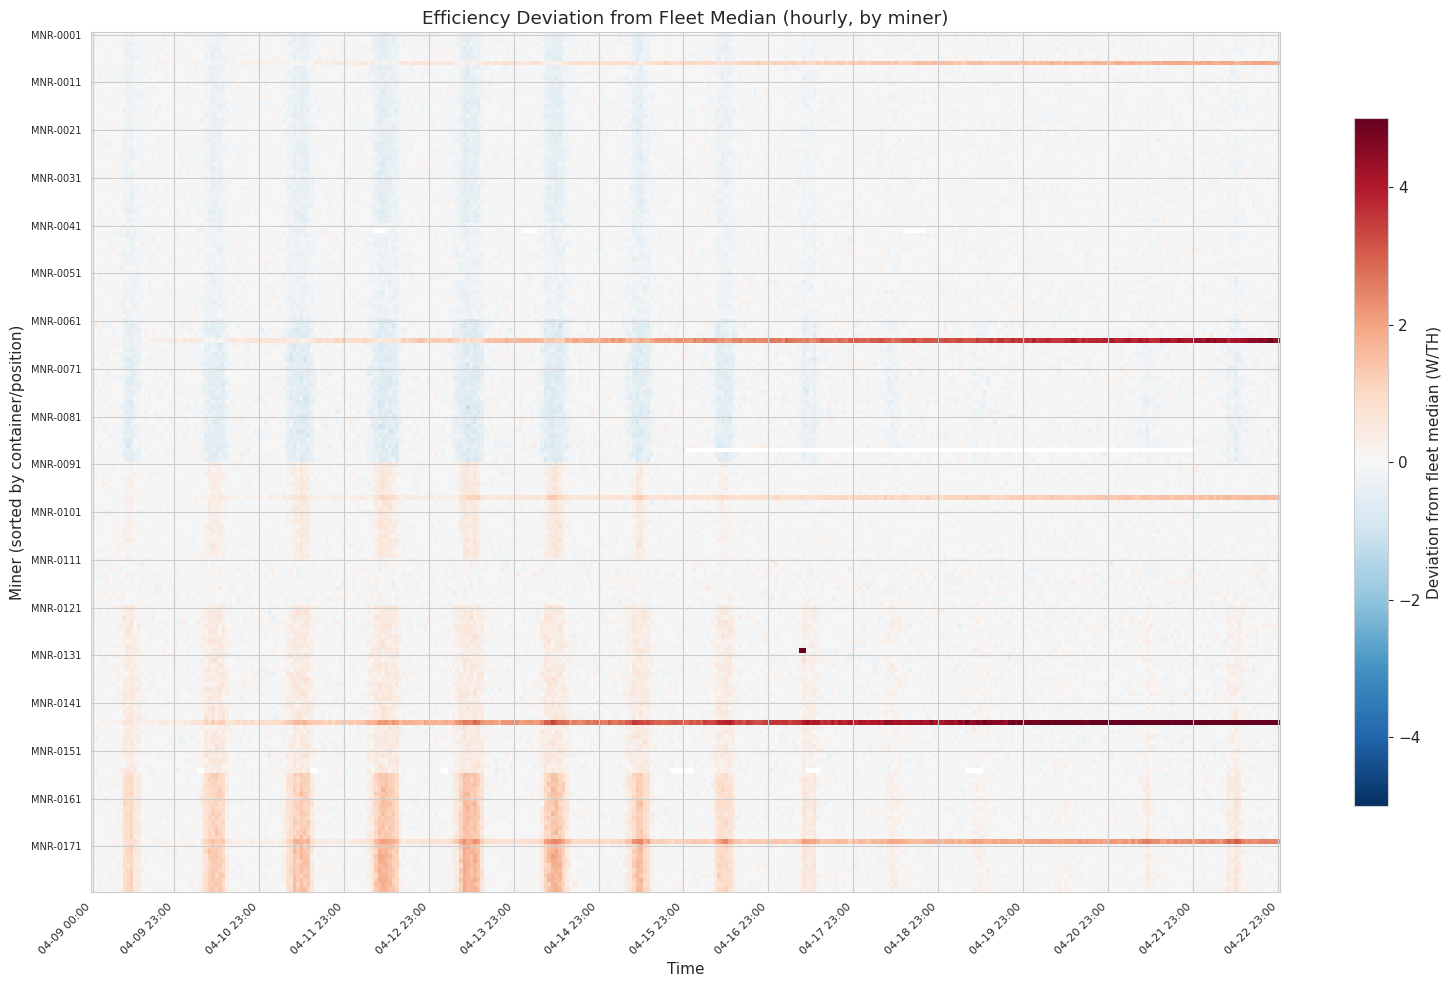

In [7]:
# Same heatmap for efficiency deviation
mining_hourly_eff = mining.set_index('timestamp').groupby('miner_id').resample('1h').agg(
    dev_efficiency=('dev_efficiency', 'mean')
).reset_index()

pivot_eff = mining_hourly_eff.pivot(index='miner_id', columns='timestamp', values='dev_efficiency')
pivot_eff = pivot_eff.reindex([m for m in miner_order if m in pivot_eff.index])

fig, ax = plt.subplots(figsize=(16, 10))
im = ax.imshow(pivot_eff.values, aspect='auto', cmap='RdBu_r', vmin=-5, vmax=5,
               interpolation='nearest')
fig.colorbar(im, ax=ax, label='Deviation from fleet median (W/TH)', shrink=0.8)

ax.set_yticks(ytick_idx)
ax.set_yticklabels(pivot_eff.index[ytick_idx], fontsize=7)
ax.set_xticks(xtick_idx)
ax.set_xticklabels([pivot_eff.columns[i].strftime('%m-%d %H:%M') for i in xtick_idx],
                    rotation=45, ha='right', fontsize=8)

ax.set_title('Efficiency Deviation from Fleet Median (hourly, by miner)')
ax.set_ylabel('Miner (sorted by container/position)')
ax.set_xlabel('Time')
plt.tight_layout()
plt.show()

---
## 4. Isolation Forest

Multivariate anomaly detection using Isolation Forest on five features:
chip_temp, efficiency, hashrate (% of nominal), reject rate, and fan speed.

In [8]:
IF_FEATURES = ['chip_temp_c', 'efficiency_wth', 'hashrate_pct', 'reject_rate', 'fan_speed_rpm']

# Prepare data — drop rows with any NaN in features
if_data = mining[['timestamp', 'miner_id', 'container', 'model'] + IF_FEATURES].dropna(subset=IF_FEATURES).copy()
print(f'Rows for Isolation Forest: {len(if_data):,} (dropped {len(mining) - len(if_data):,} with NaN features)')

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(if_data[IF_FEATURES])

# Fit Isolation Forest
iso = IsolationForest(n_estimators=200, contamination=0.01, random_state=42, n_jobs=-1)
if_data['if_label'] = iso.fit_predict(X)  # -1 = anomaly
if_data['if_score'] = iso.decision_function(X)  # lower = more anomalous

n_anom = (if_data['if_label'] == -1).sum()
print(f'Isolation Forest anomalies: {n_anom:,} ({n_anom/len(if_data)*100:.2f}%)')
print(f'Score range: [{if_data.if_score.min():.3f}, {if_data.if_score.max():.3f}]')

Rows for Isolation Forest: 716,378 (dropped 7,155 with NaN features)


Isolation Forest anomalies: 7,164 (1.00%)
Score range: [-0.100, 0.236]


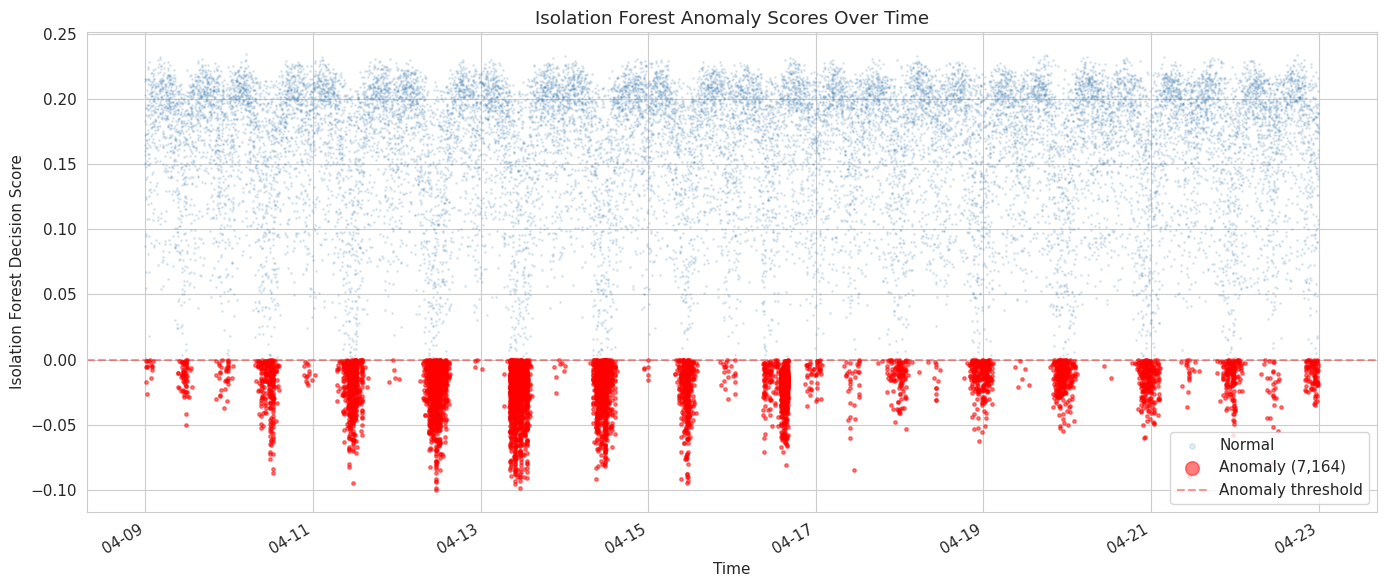

In [9]:
# Scatter: anomaly score vs time, colored by anomaly label
fig, ax = plt.subplots(figsize=(14, 6))

normal = if_data[if_data.if_label == 1]
anomal = if_data[if_data.if_label == -1]

# Sample normal for plotting speed
normal_sample = normal.sample(min(20000, len(normal)), random_state=42)
ax.scatter(normal_sample['timestamp'], normal_sample['if_score'],
           s=1, alpha=0.15, color='steelblue', label='Normal')
ax.scatter(anomal['timestamp'], anomal['if_score'],
           s=6, alpha=0.5, color='red', label=f'Anomaly ({n_anom:,})')

ax.axhline(y=if_data.loc[if_data.if_label == -1, 'if_score'].max(), color='red',
           linestyle='--', alpha=0.4, label='Anomaly threshold')
ax.set_xlabel('Time')
ax.set_ylabel('Isolation Forest Decision Score')
ax.set_title('Isolation Forest Anomaly Scores Over Time')
ax.legend(markerscale=4)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

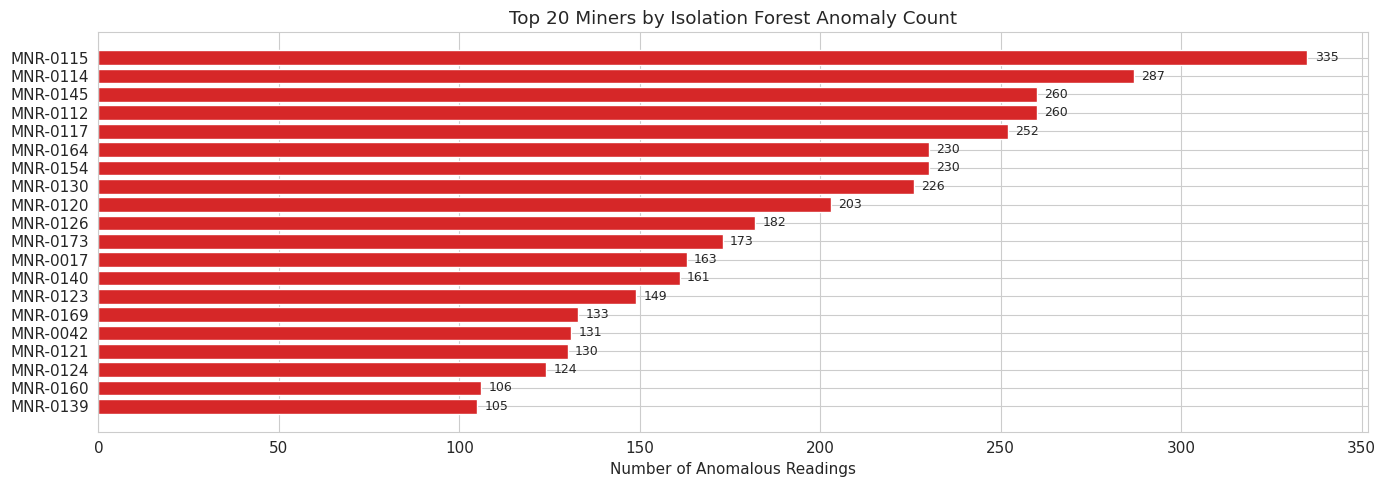

Anomalies by container:
container
C    4585
B    2107
A     472


In [10]:
# Which miners have the most Isolation Forest anomalies?
if_miner_counts = if_data[if_data.if_label == -1].groupby('miner_id').size().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
top_if = if_miner_counts.head(20)
colors_bar = [sns.color_palette('tab10')[hash(m) % 10] for m in top_if.index]
ax.barh(top_if.index[::-1], top_if.values[::-1], color='#d62728', edgecolor='white')
ax.set_xlabel('Number of Anomalous Readings')
ax.set_title('Top 20 Miners by Isolation Forest Anomaly Count')
for i, v in enumerate(top_if.values[::-1]):
    ax.text(v + 2, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()

# Breakdown by container
if_container = if_data[if_data.if_label == -1].groupby('container').size().sort_values(ascending=False)
print('Anomalies by container:')
print(if_container.to_string())

In [11]:
# Feature profile of anomalous vs normal readings
anom_mask = if_data['if_label'] == -1
comparison = pd.DataFrame({
    'Normal (mean)': if_data.loc[~anom_mask, IF_FEATURES].mean(),
    'Normal (std)': if_data.loc[~anom_mask, IF_FEATURES].std(),
    'Anomaly (mean)': if_data.loc[anom_mask, IF_FEATURES].mean(),
    'Anomaly (std)': if_data.loc[anom_mask, IF_FEATURES].std(),
})
print('Feature comparison — Normal vs Anomalous readings:')
comparison.round(2)

Feature comparison — Normal vs Anomalous readings:


,Normal (mean),Normal (std),Anomaly (mean),Anomaly (std)
chip_temp_c,64.63,6.56,75.04,11.83
efficiency_wth,19.72,2.43,23.33,3.28
hashrate_pct,99.77,4.03,91.21,7.04
reject_rate,0.00,0.00,0.00,0.00
fan_speed_rpm,4270.35,534.05,5216.41,1077.22


---
## 5. Downtime & Outage Analysis

Identify periods where status != 'mining', compute per-miner downtime,
classify as planned (sleeping) vs unplanned (offline/error), and visualize.

In [12]:
# All non-mining periods
down = tel[tel['status'] != 'mining'].copy()
down['downtime_type'] = down['status'].map({
    'sleeping': 'planned', 'offline': 'unplanned', 'error': 'unplanned'
}).fillna('unplanned')

print(f'Total non-mining readings: {len(down):,}')
print(f'By status:\n{down.status.value_counts().to_string()}')
print(f'\nBy type: {down.downtime_type.value_counts().to_dict()}')

Total non-mining readings: 2,227
By status:
status
offline    2142
error        85

By type: {'unplanned': 2227}


In [13]:
# Identify contiguous outage events per miner
# Sort by miner and time, then detect transitions
tel_sorted = tel.sort_values(['miner_id', 'timestamp']).copy()
tel_sorted['is_down'] = tel_sorted['status'] != 'mining'
tel_sorted['down_change'] = tel_sorted.groupby('miner_id')['is_down'].transform(
    lambda x: x != x.shift()
)
tel_sorted['event_id'] = tel_sorted.groupby('miner_id')['down_change'].cumsum()

# Extract outage events
outages_raw = tel_sorted[tel_sorted.is_down].copy()
outage_events = outages_raw.groupby(['miner_id', 'event_id']).agg(
    start=('timestamp', 'min'),
    end=('timestamp', 'max'),
    n_readings=('timestamp', 'size'),
    status=('status', 'first'),
    container=('container', 'first'),
    model=('model', 'first'),
).reset_index()

outage_events['duration_hours'] = (outage_events['end'] - outage_events['start']).dt.total_seconds() / 3600 + 5/60
outage_events['downtime_type'] = outage_events['status'].map(
    {'sleeping': 'planned', 'offline': 'unplanned', 'error': 'unplanned'}
).fillna('unplanned')

print(f'Total outage events: {len(outage_events)}')
print(f'  Planned:   {(outage_events.downtime_type=="planned").sum()}')
print(f'  Unplanned: {(outage_events.downtime_type=="unplanned").sum()}')
print(f'\nMean duration: {outage_events.duration_hours.mean():.2f} hours')
print(f'Max duration:  {outage_events.duration_hours.max():.2f} hours')

Total outage events: 62
  Planned:   0
  Unplanned: 62

Mean duration: 2.99 hours
Max duration:  144.00 hours


In [14]:
# Per-miner summary
miner_downtime = outage_events.groupby('miner_id').agg(
    total_downtime_h=('duration_hours', 'sum'),
    n_events=('event_id', 'count'),
    unplanned_events=('downtime_type', lambda x: (x == 'unplanned').sum()),
).reset_index()

# MTBF — mean time between failures (between start of consecutive events)
def calc_mtbf(group):
    starts = group.sort_values('start')['start']
    if len(starts) < 2:
        return np.nan
    gaps = starts.diff().dropna().dt.total_seconds() / 3600
    return gaps.mean()

mtbf = outage_events.groupby('miner_id').apply(calc_mtbf).rename('mtbf_hours')
miner_downtime = miner_downtime.merge(mtbf, on='miner_id', how='left')

miner_downtime = miner_downtime.sort_values('total_downtime_h', ascending=False)
print('Top 15 miners by total downtime:')
miner_downtime.head(15).round(2)

Top 15 miners by total downtime:


,miner_id,total_downtime_h,n_events,unplanned_events,mtbf_hours
2,MNR-0088,144.00,1,1,NaN
15,MNR-0155,21.00,6,6,43.40
1,MNR-0042,13.50,3,3,75.00
16,MNR-0160,1.67,7,7,7.90
8,MNR-0130,0.92,5,5,0.42
18,MNR-0169,0.92,7,7,0.28
14,MNR-0154,0.58,5,5,0.23
0,MNR-0033,0.50,1,1,NaN
19,MNR-0173,0.50,5,5,0.27
3,MNR-0123,0.42,5,5,0.27


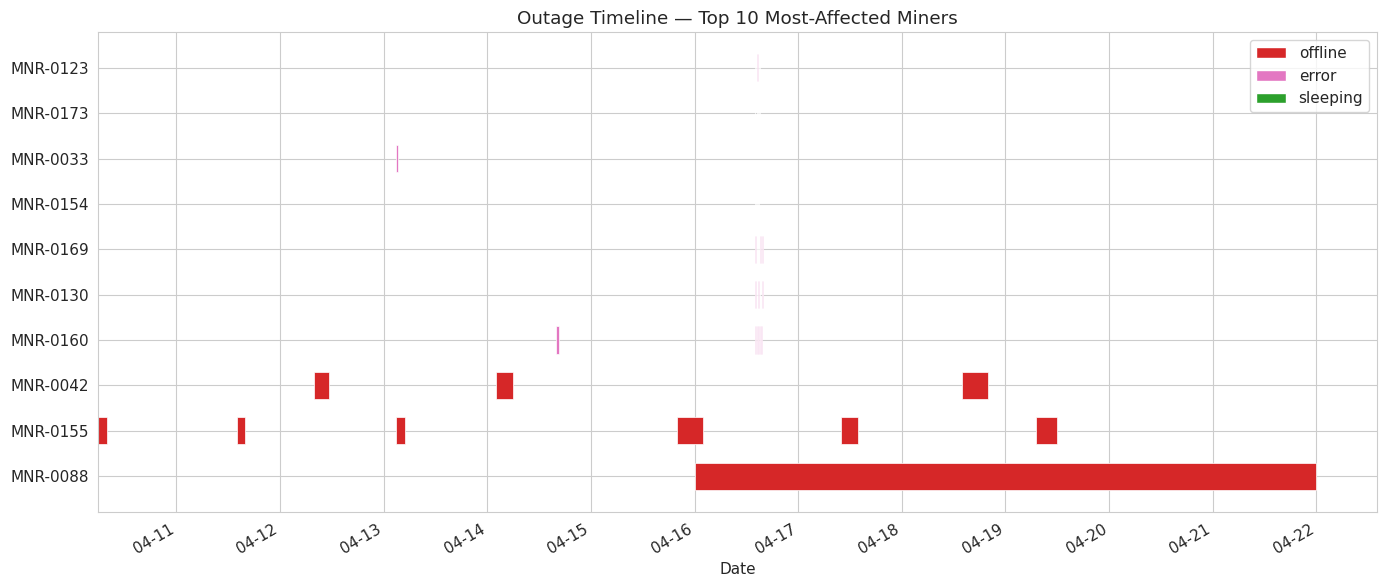

In [15]:
# Gantt-style chart for top 10 most-affected miners
top_down_miners = miner_downtime.head(10)['miner_id'].tolist()
top_outages = outage_events[outage_events.miner_id.isin(top_down_miners)].copy()

fig, ax = plt.subplots(figsize=(14, 6))

color_map = {'offline': '#d62728', 'error': '#e377c2', 'sleeping': '#2ca02c'}

for i, miner in enumerate(top_down_miners):
    events = top_outages[top_outages.miner_id == miner]
    for _, ev in events.iterrows():
        width = max((ev['end'] - ev['start']).total_seconds() / 3600, 0.1)
        ax.barh(i, width / 24, left=mdates.date2num(ev['start']),
                height=0.6, color=color_map.get(ev['status'], 'gray'),
                edgecolor='white', linewidth=0.5)

ax.set_yticks(range(len(top_down_miners)))
ax.set_yticklabels(top_down_miners)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.set_xlabel('Date')
ax.set_title('Outage Timeline — Top 10 Most-Affected Miners')

# Legend
from matplotlib.patches import Patch
legend_elems = [Patch(facecolor=c, label=s) for s, c in color_map.items()]
ax.legend(handles=legend_elems, loc='upper right')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

---
## 6. Container-Level Anomalies

Detect correlated events across miners in the same container.
A cooling failure would cause multiple miners in the same container to spike simultaneously.

In [16]:
# Per container per timestamp: mean and max chip_temp deviation, count of anomalous miners
container_ts = mining.groupby(['timestamp', 'container']).agg(
    mean_chip_temp=('chip_temp_c', 'mean'),
    max_chip_temp=('chip_temp_c', 'max'),
    mean_dev_temp=('dev_chip_temp', 'mean'),
    n_ctx_anom=('ctx_anom_temp', 'sum'),
    n_z_anom_temp=('anom_z_chip_temp_c', 'sum'),
    n_miners=('miner_id', 'count'),
    mean_efficiency=('efficiency_wth', 'mean'),
).reset_index()

container_ts['pct_anomalous'] = container_ts['n_z_anom_temp'] / container_ts['n_miners'] * 100

# Container-wide events: >30% of miners in the container show z-score temp anomaly
container_events = container_ts[container_ts['pct_anomalous'] > 30].copy()
print(f'Container-wide thermal events (>30% miners anomalous): {len(container_events)}')
if len(container_events) > 0:
    print(container_events.groupby('container').agg(
        n_timestamps=('timestamp', 'count'),
        first=('timestamp', 'min'),
        last=('timestamp', 'max'),
        max_temp=('max_chip_temp', 'max'),
    ).to_string())

Container-wide thermal events (>30% miners anomalous): 16
           n_timestamps               first                last  max_temp
container                                                                
C                    16 2026-04-16 14:00:00 2026-04-16 15:40:00      90.0


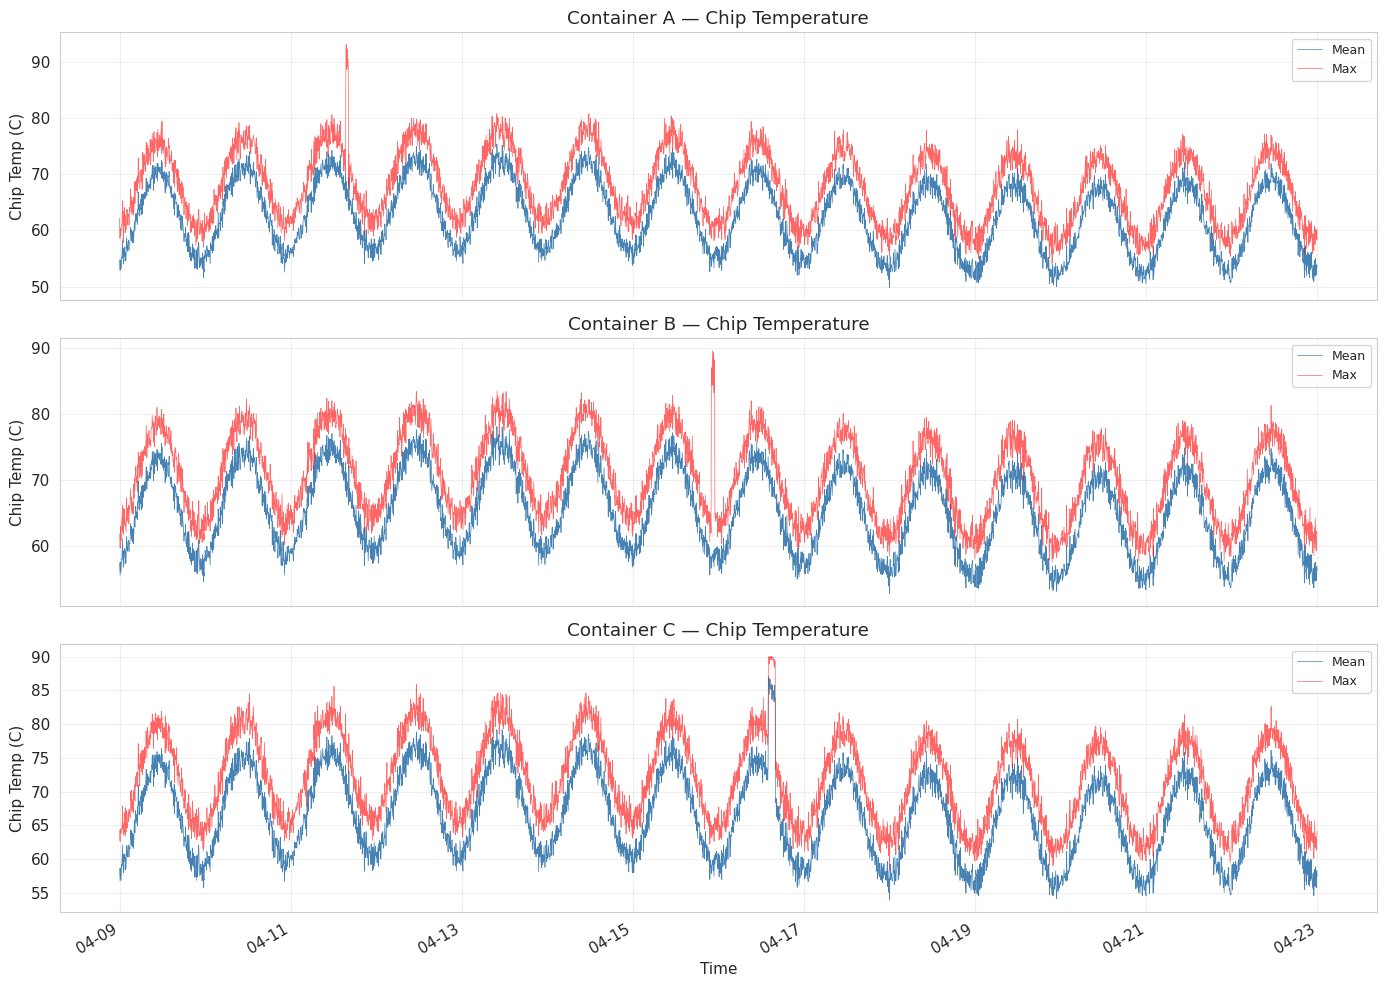

In [17]:
# Timeline of container mean chip_temp — look for spikes
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for idx, container in enumerate(sorted(container_ts.container.unique())):
    ax = axes[idx]
    cdata = container_ts[container_ts.container == container]
    ax.plot(cdata['timestamp'], cdata['mean_chip_temp'], linewidth=0.5, color='steelblue', label='Mean')
    ax.plot(cdata['timestamp'], cdata['max_chip_temp'], linewidth=0.5, color='red', alpha=0.6, label='Max')
    ax.set_ylabel('Chip Temp (C)')
    ax.set_title(f'Container {container} — Chip Temperature')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
axes[-1].set_xlabel('Time')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

Worst container event: Container C at 2026-04-16 14:00:00
  100% of miners anomalous, max temp = 89.8C


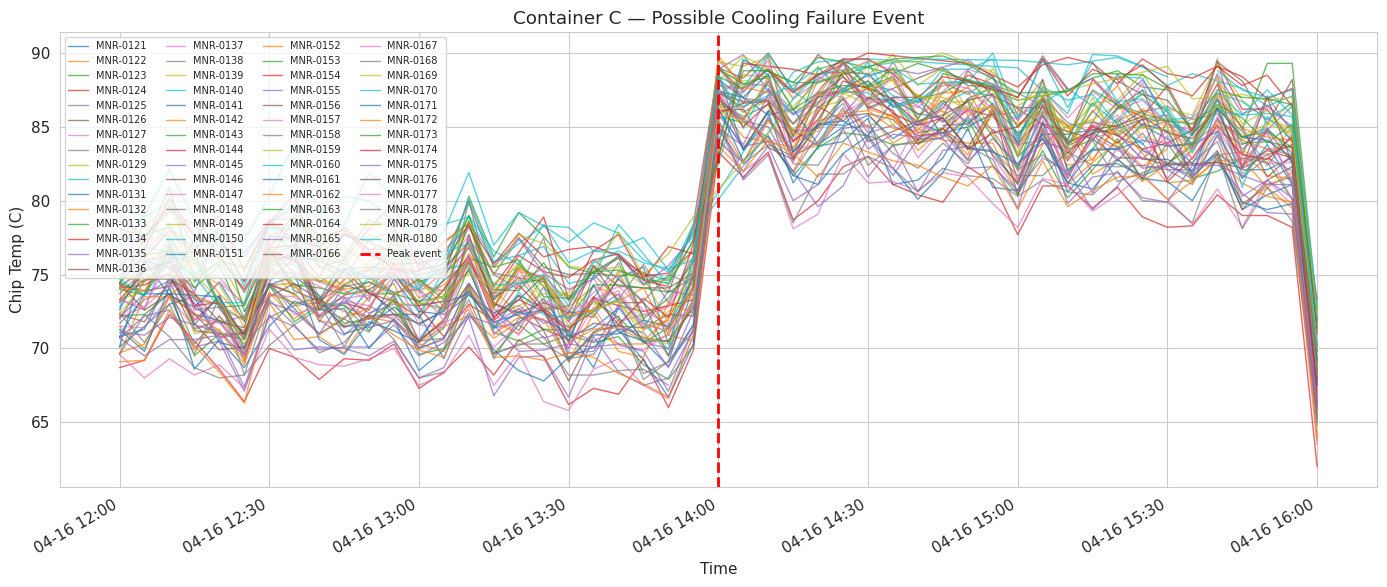

In [18]:
# Identify the biggest container-wide event (cooling failure candidate)
# Find timestamps where any container has highest pct_anomalous
if len(container_events) > 0:
    worst_event = container_events.sort_values('pct_anomalous', ascending=False).head(1)
    evt_container = worst_event.container.values[0]
    evt_time = worst_event.timestamp.values[0]
    evt_time_pd = pd.Timestamp(evt_time)
    
    print(f'Worst container event: Container {evt_container} at {evt_time_pd}')
    print(f'  {worst_event.pct_anomalous.values[0]:.0f}% of miners anomalous, '
          f'max temp = {worst_event.max_chip_temp.values[0]:.1f}C')
    
    # Show all miners in that container around that time
    window = pd.Timedelta('2h')
    nearby = mining[(mining.container == evt_container) &
                    (mining.timestamp >= evt_time_pd - window) &
                    (mining.timestamp <= evt_time_pd + window)]
    
    fig, ax = plt.subplots(figsize=(14, 6))
    for miner in nearby.miner_id.unique():
        mdata = nearby[nearby.miner_id == miner]
        ax.plot(mdata['timestamp'], mdata['chip_temp_c'], linewidth=1, alpha=0.7, label=miner)
    ax.axvline(x=evt_time_pd, color='red', linestyle='--', linewidth=2, label='Peak event')
    ax.set_xlabel('Time')
    ax.set_ylabel('Chip Temp (C)')
    ax.set_title(f'Container {evt_container} — Possible Cooling Failure Event')
    ax.legend(fontsize=7, ncol=4, loc='upper left')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()
else:
    # Even without >30% threshold, show the highest-temp moments per container
    print('No container-wide events above 30% threshold. Showing peak temp moments:')
    for container in sorted(container_ts.container.unique()):
        cdata = container_ts[container_ts.container == container]
        peak = cdata.loc[cdata.max_chip_temp.idxmax()]
        print(f'  Container {container}: peak {peak.max_chip_temp:.1f}C at {peak.timestamp}')

---
## 7. Correlation of Anomalies with Operating Conditions

Examine whether anomalies cluster at specific times of day, correlate with
inlet temperature, or vary by hardware model.

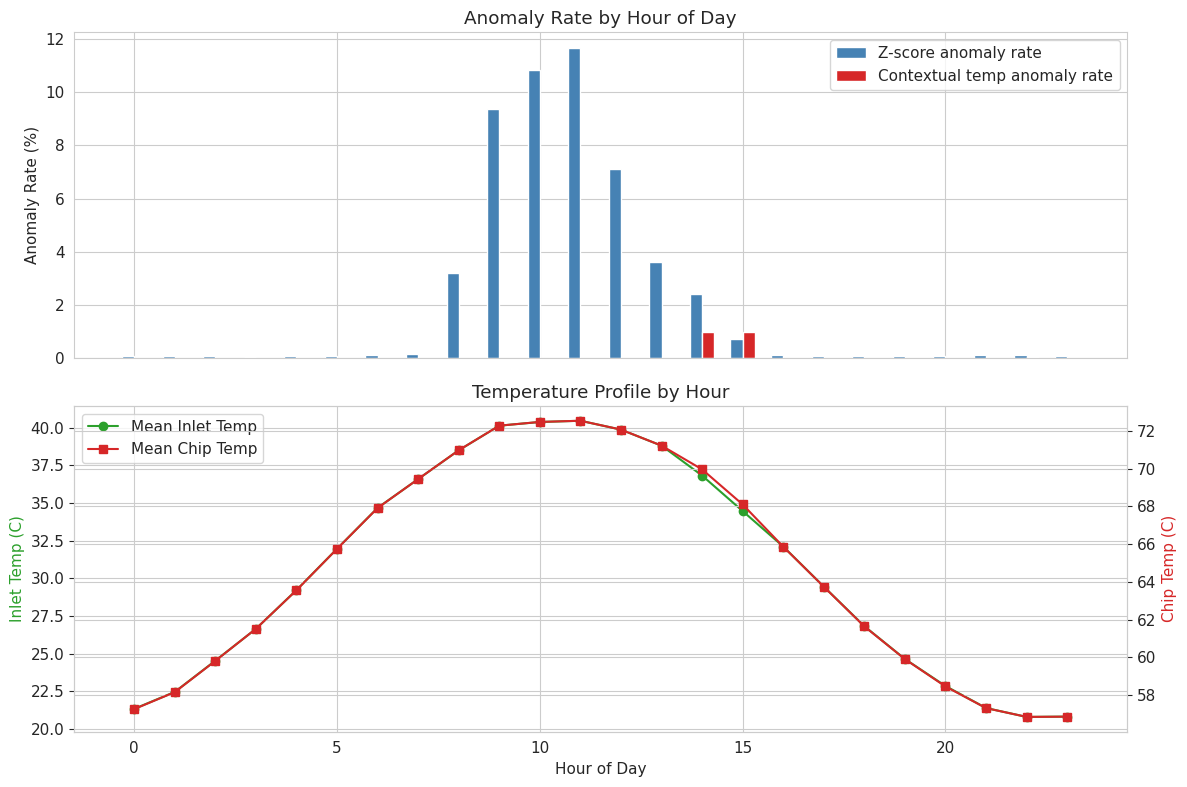

In [19]:
# Anomaly rate by hour of day
hourly_anom = mining.groupby('hour').agg(
    z_anom_rate=('any_z_anom', 'mean'),
    ctx_temp_rate=('ctx_anom_temp', 'mean'),
    mean_inlet=('inlet_temp_c', 'mean'),
    mean_chip=('chip_temp_c', 'mean'),
).reset_index()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Anomaly rates
ax1.bar(hourly_anom['hour'] - 0.15, hourly_anom['z_anom_rate'] * 100, width=0.3,
        color='steelblue', label='Z-score anomaly rate')
ax1.bar(hourly_anom['hour'] + 0.15, hourly_anom['ctx_temp_rate'] * 100, width=0.3,
        color='#d62728', label='Contextual temp anomaly rate')
ax1.set_ylabel('Anomaly Rate (%)')
ax1.set_title('Anomaly Rate by Hour of Day')
ax1.legend()

# Temperatures by hour
ax2.plot(hourly_anom['hour'], hourly_anom['mean_inlet'], 'o-', color='#2ca02c', label='Mean Inlet Temp')
ax2t = ax2.twinx()
ax2t.plot(hourly_anom['hour'], hourly_anom['mean_chip'], 's-', color='#d62728', label='Mean Chip Temp')
ax2.set_xlabel('Hour of Day')
ax2.set_ylabel('Inlet Temp (C)', color='#2ca02c')
ax2t.set_ylabel('Chip Temp (C)', color='#d62728')
ax2.set_title('Temperature Profile by Hour')
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2t.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

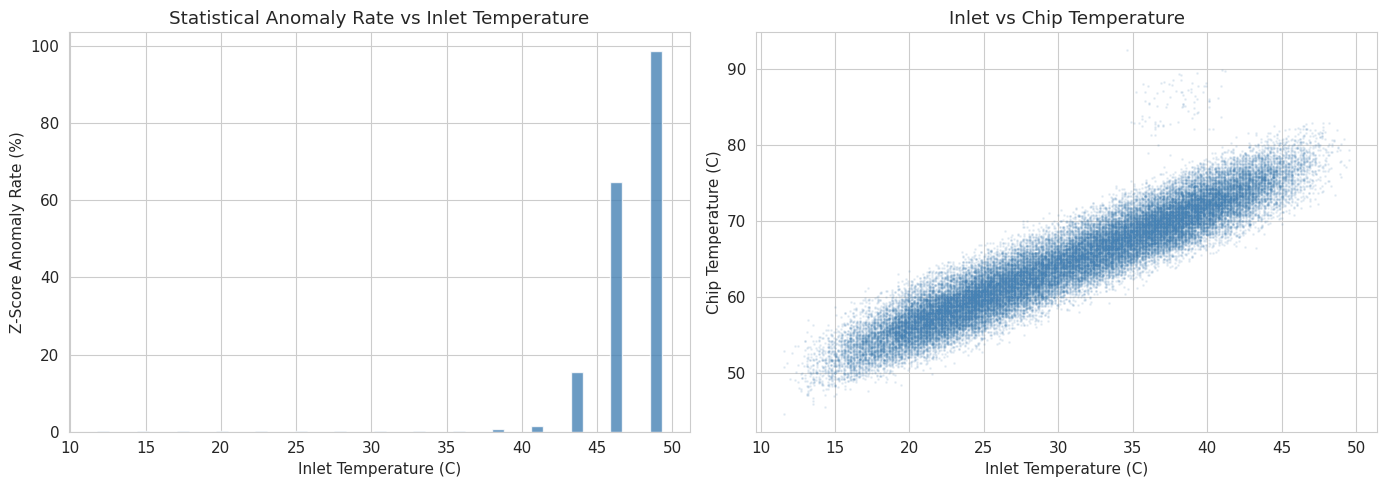

In [20]:
# Relationship between inlet_temp and anomaly rate
mining['inlet_bin'] = pd.cut(mining['inlet_temp_c'], bins=15)
inlet_anom = mining.groupby('inlet_bin', observed=True).agg(
    z_anom_rate=('any_z_anom', 'mean'),
    ctx_temp_rate=('ctx_anom_temp', 'mean'),
    count=('miner_id', 'size'),
    mean_chip=('chip_temp_c', 'mean'),
).reset_index()
inlet_anom['inlet_mid'] = inlet_anom['inlet_bin'].apply(lambda x: x.mid)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(inlet_anom['inlet_mid'], inlet_anom['z_anom_rate'] * 100, width=0.8,
        color='steelblue', alpha=0.8)
ax1.set_xlabel('Inlet Temperature (C)')
ax1.set_ylabel('Z-Score Anomaly Rate (%)')
ax1.set_title('Statistical Anomaly Rate vs Inlet Temperature')

ax2.scatter(mining.sample(50000, random_state=42)['inlet_temp_c'],
            mining.sample(50000, random_state=42)['chip_temp_c'],
            s=1, alpha=0.1, color='steelblue')
ax2.set_xlabel('Inlet Temperature (C)')
ax2.set_ylabel('Chip Temperature (C)')
ax2.set_title('Inlet vs Chip Temperature')

plt.tight_layout()
plt.show()

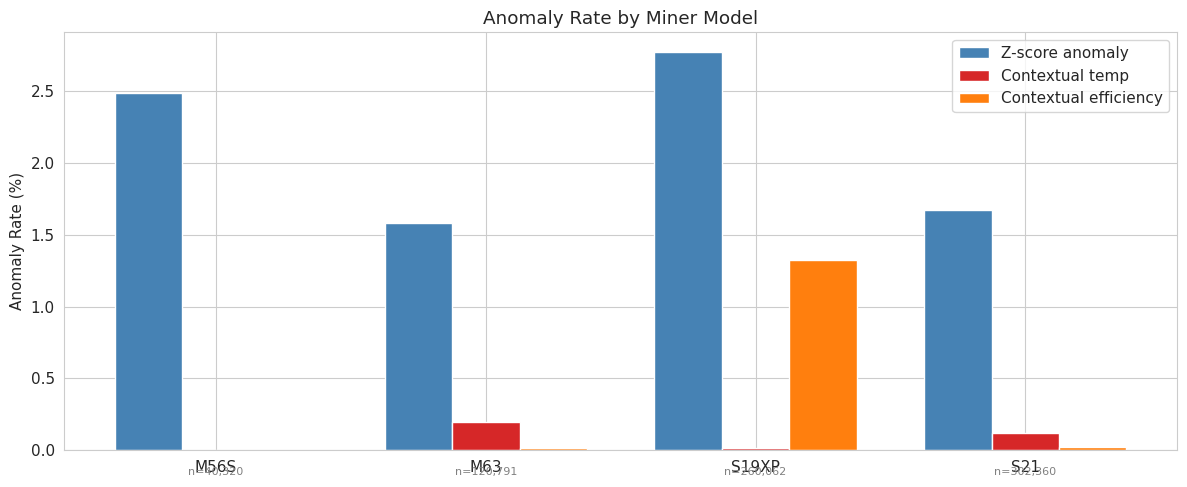


Model anomaly summary:


,model,n_readings,z_anom_rate,ctx_temp_rate,ctx_eff_rate,mean_chip,mean_efficiency,mean_reject_rate
0,M56S,40320,0.0249,0.0000,0.0000,64.8514,25.6463,0.0
1,M63,120791,0.0159,0.0019,0.0001,63.9076,18.6083,0.0
2,S19XP,260062,0.0277,0.0001,0.0132,66.0109,21.8274,0.0
3,S21,302360,0.0167,0.0012,0.0002,63.9457,17.6362,0.0


In [21]:
# Anomaly rates by model
model_anom = mining.groupby('model').agg(
    n_readings=('miner_id', 'size'),
    z_anom_rate=('any_z_anom', 'mean'),
    ctx_temp_rate=('ctx_anom_temp', 'mean'),
    ctx_eff_rate=('ctx_anom_eff', 'mean'),
    mean_chip=('chip_temp_c', 'mean'),
    mean_efficiency=('efficiency_wth', 'mean'),
    mean_reject_rate=('reject_rate', 'mean'),
).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(model_anom))
width = 0.25
ax.bar(x - width, model_anom['z_anom_rate'] * 100, width, label='Z-score anomaly', color='steelblue')
ax.bar(x, model_anom['ctx_temp_rate'] * 100, width, label='Contextual temp', color='#d62728')
ax.bar(x + width, model_anom['ctx_eff_rate'] * 100, width, label='Contextual efficiency', color='#ff7f0e')

ax.set_xticks(x)
ax.set_xticklabels(model_anom['model'])
ax.set_ylabel('Anomaly Rate (%)')
ax.set_title('Anomaly Rate by Miner Model')
ax.legend()

# Annotate with reading counts
for i, row in model_anom.iterrows():
    ax.annotate(f'n={row.n_readings:,.0f}', (i, 0), textcoords='offset points',
                xytext=(0, -18), ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.show()

print('\nModel anomaly summary:')
model_anom.round(4)

---
## 8. Anomaly Summary & Operational Interpretation

Consolidate detected events into an actionable summary with severity and recommendations.

In [22]:
# Build anomaly event table
# Combine z-score anomalies into contiguous events per miner
events = []

# --- Persistent temperature anomalies (z-score, at least 3 consecutive readings = 15 min) ---
temp_anom = mining[mining['anom_z_chip_temp_c']].sort_values(['miner_id', 'timestamp']).copy()
if len(temp_anom) > 0:
    temp_anom['gap'] = temp_anom.groupby('miner_id')['timestamp'].diff() > pd.Timedelta('10m')
    temp_anom['event_group'] = temp_anom.groupby('miner_id')['gap'].cumsum()
    temp_events = temp_anom.groupby(['miner_id', 'event_group']).agg(
        start=('timestamp', 'min'), end=('timestamp', 'max'),
        n_readings=('timestamp', 'size'),
        max_temp=('chip_temp_c', 'max'),
        mean_z=('z_chip_temp_c', 'mean'),
        container=('container', 'first'),
    ).reset_index()
    temp_events = temp_events[temp_events.n_readings >= 3]
    for _, e in temp_events.iterrows():
        severity = 'CRITICAL' if e.max_temp > 85 else ('HIGH' if e.max_temp > 75 else 'MEDIUM')
        events.append({
            'time': f"{e.start.strftime('%m-%d %H:%M')} to {e.end.strftime('%H:%M')}",
            'miner': e.miner_id, 'container': e.container,
            'type': 'Sustained high chip temp',
            'severity': severity,
            'detail': f'max={e.max_temp:.0f}C, mean_z={e.mean_z:.1f}, {e.n_readings} readings',
            'probable_cause': 'Cooling degradation / dust / fan failure',
            'action': 'Inspect cooling' if severity != 'CRITICAL' else 'IMMEDIATE: throttle or shut down',
        })

# --- Unplanned outages ---
unplanned = outage_events[outage_events.downtime_type == 'unplanned']
for _, e in unplanned.iterrows():
    severity = 'HIGH' if e.duration_hours > 2 else ('MEDIUM' if e.duration_hours > 0.5 else 'LOW')
    events.append({
        'time': f"{e.start.strftime('%m-%d %H:%M')} ({e.duration_hours:.1f}h)",
        'miner': e.miner_id, 'container': e.container,
        'type': f'Unplanned outage ({e.status})',
        'severity': severity,
        'detail': f'{e.n_readings} readings, {e.duration_hours:.1f} hours',
        'probable_cause': 'PSU failure / network / firmware crash' if e.status == 'offline' else 'Hardware error',
        'action': 'Investigate root cause' if severity == 'HIGH' else 'Monitor',
    })

# --- Container-wide events ---
if len(container_events) > 0:
    ce_grouped = container_events.groupby('container').agg(
        start=('timestamp', 'min'), end=('timestamp', 'max'),
        max_temp=('max_chip_temp', 'max'),
        max_pct=('pct_anomalous', 'max'),
        n_timestamps=('timestamp', 'count'),
    ).reset_index()
    for _, e in ce_grouped.iterrows():
        events.append({
            'time': f"{e.start.strftime('%m-%d %H:%M')} to {e.end.strftime('%m-%d %H:%M')}",
            'miner': f'Container {e.container} (all)', 'container': e.container,
            'type': 'Container-wide thermal event',
            'severity': 'CRITICAL',
            'detail': f'{e.max_pct:.0f}% miners anomalous, max {e.max_temp:.0f}C, {e.n_timestamps} intervals',
            'probable_cause': 'Cooling system failure / ambient spike',
            'action': 'IMMEDIATE: check HVAC, consider emergency shutdown',
        })

events_df = pd.DataFrame(events)

# Sort by severity
sev_order = {'CRITICAL': 0, 'HIGH': 1, 'MEDIUM': 2, 'LOW': 3}
if len(events_df) > 0:
    events_df['sev_rank'] = events_df['severity'].map(sev_order)
    events_df = events_df.sort_values('sev_rank').drop(columns='sev_rank')

print(f'Total anomalous events cataloged: {len(events_df)}')
if len(events_df) > 0:
    print(f'By severity: {events_df.severity.value_counts().to_dict()}')
    print(f'By type: {events_df.type.value_counts().to_dict()}')

Total anomalous events cataloged: 146
By severity: {'CRITICAL': 72, 'LOW': 51, 'HIGH': 19, 'MEDIUM': 4}
By type: {'Sustained high chip temp': 83, 'Unplanned outage (error)': 52, 'Unplanned outage (offline)': 10, 'Container-wide thermal event': 1}


In [23]:
# Display the event table (top 30)
if len(events_df) > 0:
    display_cols = ['severity', 'time', 'miner', 'container', 'type', 'detail', 'probable_cause', 'action']
    with pd.option_context('display.max_colwidth', 60, 'display.max_rows', 30):
        display(events_df[display_cols].head(30))
else:
    print('No events above thresholds detected — fleet is operating nominally.')

,severity,time,miner,container,type,detail,probable_cause,action
0,CRITICAL,04-11 15:30 to 16:10,MNR-0015,A,Sustained high chip temp,"max=93C, mean_z=4.8, 9 readings",Cooling degradation / dust / fan failure,IMMEDIATE: throttle or shut down
1,CRITICAL,04-15 22:05 to 22:55,MNR-0071,B,Sustained high chip temp,"max=90C, mean_z=3.5, 10 readings",Cooling degradation / dust / fan failure,IMMEDIATE: throttle or shut down
2,CRITICAL,04-16 14:00 to 15:05,MNR-0121,C,Sustained high chip temp,"max=88C, mean_z=3.2, 10 readings",Cooling degradation / dust / fan failure,IMMEDIATE: throttle or shut down
3,CRITICAL,04-16 14:00 to 15:10,MNR-0122,C,Sustained high chip temp,"max=86C, mean_z=3.1, 12 readings",Cooling degradation / dust / fan failure,IMMEDIATE: throttle or shut down
4,CRITICAL,04-16 14:20 to 14:45,MNR-0123,C,Sustained high chip temp,"max=90C, mean_z=3.1, 5 readings",Cooling degradation / dust / fan failure,IMMEDIATE: throttle or shut down
5,CRITICAL,04-16 14:00 to 14:30,MNR-0124,C,Sustained high chip temp,"max=89C, mean_z=3.2, 7 readings",Cooling degradation / dust / fan failure,IMMEDIATE: throttle or shut down
6,CRITICAL,04-16 14:00 to 15:25,MNR-0125,C,Sustained high chip temp,"max=87C, mean_z=3.2, 14 readings",Cooling degradation / dust / fan failure,IMMEDIATE: throttle or shut down
7,CRITICAL,04-16 14:00 to 14:20,MNR-0126,C,Sustained high chip temp,"max=90C, mean_z=3.2, 4 readings",Cooling degradation / dust / fan failure,IMMEDIATE: throttle or shut down
8,CRITICAL,04-16 15:40 to 15:55,MNR-0126,C,Sustained high chip temp,"max=89C, mean_z=3.1, 3 readings",Cooling degradation / dust / fan failure,IMMEDIATE: throttle or shut down
9,CRITICAL,04-16 14:00 to 15:25,MNR-0127,C,Sustained high chip temp,"max=90C, mean_z=3.2, 14 readings",Cooling degradation / dust / fan failure,IMMEDIATE: throttle or shut down


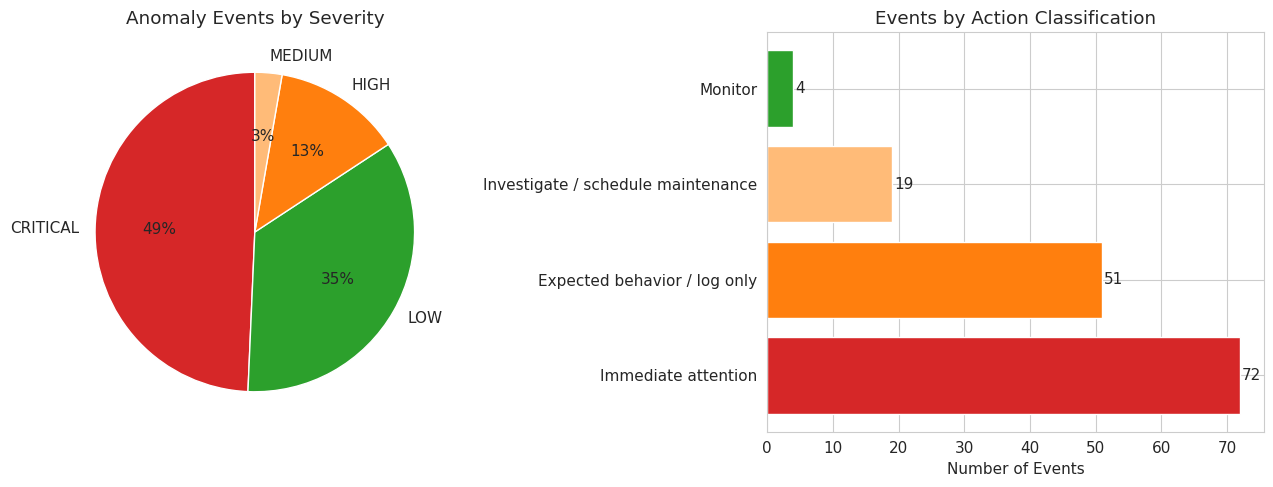

In [24]:
# Severity distribution and action classification
if len(events_df) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    # Severity pie
    sev_counts = events_df.severity.value_counts()
    sev_colors = {'CRITICAL': '#d62728', 'HIGH': '#ff7f0e', 'MEDIUM': '#ffbb78', 'LOW': '#2ca02c'}
    ax1.pie(sev_counts.values, labels=sev_counts.index, autopct='%1.0f%%',
            colors=[sev_colors.get(s, 'gray') for s in sev_counts.index], startangle=90)
    ax1.set_title('Anomaly Events by Severity')

    # Action classification
    action_map = {
        'CRITICAL': 'Immediate attention',
        'HIGH': 'Investigate / schedule maintenance',
        'MEDIUM': 'Monitor',
        'LOW': 'Expected behavior / log only',
    }
    events_df['action_class'] = events_df.severity.map(action_map)
    ac = events_df.action_class.value_counts()
    ax2.barh(ac.index, ac.values, color=['#d62728', '#ff7f0e', '#ffbb78', '#2ca02c'][:len(ac)])
    ax2.set_xlabel('Number of Events')
    ax2.set_title('Events by Action Classification')
    for i, v in enumerate(ac.values):
        ax2.text(v + 0.3, i, str(v), va='center')

    plt.tight_layout()
    plt.show()

In [25]:
# Final summary statistics
print('=' * 70)
print('ANOMALY DETECTION SUMMARY')
print('=' * 70)
print(f'\nDataset: {len(tel):,} readings, {tel.miner_id.nunique()} miners, '
      f'{(tel.timestamp.max() - tel.timestamp.min()).days} days')
print(f'Mining readings analyzed: {len(mining):,}')

print(f'\n--- Statistical Anomalies ---')
print(f'Z-score (|z|>3):  {mining.any_z_anom.sum():,} readings ({mining.any_z_anom.mean()*100:.2f}%)')
print(f'IQR outliers:     {mining.any_iqr_anom.sum():,} readings ({mining.any_iqr_anom.mean()*100:.2f}%)')

print(f'\n--- Contextual Anomalies ---')
print(f'Temp >10C above fleet: {mining.ctx_anom_temp.sum():,} readings')
print(f'Eff >3 W/TH above fleet: {mining.ctx_anom_eff.sum():,} readings')

print(f'\n--- Isolation Forest ---')
if_anom_n = (if_data.if_label == -1).sum()
print(f'Anomalous readings: {if_anom_n:,} ({if_anom_n/len(if_data)*100:.2f}%)')
print(f'Miners with >50 IF anomalies: {(if_miner_counts > 50).sum()}')

print(f'\n--- Downtime ---')
print(f'Total outage events: {len(outage_events)}')
print(f'  Unplanned: {(outage_events.downtime_type=="unplanned").sum()}')
print(f'  Total unplanned downtime: {outage_events[outage_events.downtime_type=="unplanned"].duration_hours.sum():.1f} hours')
print(f'  Miners with >0 unplanned events: {miner_downtime[miner_downtime.unplanned_events > 0].shape[0]}')

print(f'\n--- Container Events ---')
print(f'Container-wide thermal events: {len(container_events)} timestamp-container pairs')

if len(events_df) > 0:
    print(f'\n--- Action Items ---')
    for sev in ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW']:
        n = (events_df.severity == sev).sum()
        if n > 0:
            print(f'  {sev:10s}: {n} events')
print('=' * 70)

ANOMALY DETECTION SUMMARY

Dataset: 725,760 readings, 180 miners, 13 days
Mining readings analyzed: 723,533

--- Statistical Anomalies ---
Z-score (|z|>3):  15,182 readings (2.10%)
IQR outliers:     43,183 readings (5.97%)

--- Contextual Anomalies ---
Temp >10C above fleet: 619 readings
Eff >3 W/TH above fleet: 3,525 readings

--- Isolation Forest ---
Anomalous readings: 7,164 (1.00%)
Miners with >50 IF anomalies: 41

--- Downtime ---
Total outage events: 62
  Unplanned: 62
  Total unplanned downtime: 185.6 hours
  Miners with >0 unplanned events: 21

--- Container Events ---
Container-wide thermal events: 16 timestamp-container pairs

--- Action Items ---
  CRITICAL  : 72 events
  HIGH      : 19 events
  MEDIUM    : 4 events
  LOW       : 51 events
